<a href="https://colab.research.google.com/github/KalonzoBrian/LEARNING-PYTHON/blob/main/Functions_numpy_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Lab 1 - Variables & types ● Run in Colab
# Variables: store values with a name
county = "Nairobi"
population = 4397073
gdp_share = 0.45
# 45% of Kenya's GDP
has_4g = True
# f-strings: the cleanest way to build messages
print(f"{county} has a population of {population:,}")
print(f"Contributes {gdp_share:.0%} of Kenya's GDP")
# Check a variable's type
print(type(population))
# <class 'int'>
print(type(gdp_share))
# <class 'float'>

Nairobi has a population of 4,397,073
Contributes 45% of Kenya's GDP
<class 'int'>
<class 'float'>


In [3]:
#Lab 2 - Data structures

# ── LISTS: ordered, changeable ──────────────────────────
counties = ["Nairobi", "Mombasa", "Kisumu", "Nakuru", "Eldoret"]
print(counties[0]) # "Nairobi" - indexing starts at 0
print(counties[-1]) # "Eldoret" - negative index = from end
print(counties[1:3]) # ["Mombasa", "Kisumu"] - slicing
counties.append("Thika") # add to end
print(len(counties)) # 6

# ── TUPLES: ordered, fixed (immutable) ──────────────────
coordinates = (-1.286389, 36.817223) # Nairobi lat/lon
lat, lon = coordinates # unpacking
print(f"Lat: {lat}, Lon: {lon}")

# ── DICTIONARIES: key-value pairs ───────────────────────
learner = {
    "name": "Aisha",
    "county": "Mombasa",
    "score": 87,
    "has_laptop": True
}
print(learner["name"]) # "Aisha"
learner["score"] = 92 # update a value
print(learner.keys()) # all keys
print(learner.values()) # all values

Nairobi
Eldoret
['Mombasa', 'Kisumu']
6
Lat: -1.286389, Lon: 36.817223
Aisha
dict_keys(['name', 'county', 'score', 'has_laptop'])
dict_values(['Aisha', 'Mombasa', 92, True])


In [4]:
#Lab 3 - Loops & conditionals

# ── FOR LOOPS ────────────────────────────────────────────
m_pesa_transactions = [500, 12000, 250, 75000, 1800, 300000]
for amount in m_pesa_transactions:
    if amount > 50000:
        print(f"⚠ Flag for review: Ksh {amount:,}")
    elif amount > 10000:
        print(f"✓ Large: Ksh {amount:,}")
    else:
        print(f" Normal: Ksh {amount:,}")

# ── WHILE LOOPS ──────────────────────────────────────────
attempts = 0
while attempts < 3:
    print(f"Login attempt {attempts + 1}")
    attempts += 1

# ── LIST COMPREHENSIONS: compact loops ──────────────────
# Get only flagged transactions in one line
flagged = [t for t in m_pesa_transactions if t > 50000]
print(f"Flagged: {flagged}")

 Normal: Ksh 500
✓ Large: Ksh 12,000
 Normal: Ksh 250
⚠ Flag for review: Ksh 75,000
 Normal: Ksh 1,800
⚠ Flag for review: Ksh 300,000
Login attempt 1
Login attempt 2
Login attempt 3
Flagged: [75000, 300000]


In [5]:
#Lab 4 - Functions

# ── DEFINING FUNCTIONS ───────────────────────────────────
def flag_transaction(amount, threshold=50000):
    """Return True if a transaction exceeds the threshold."""
    return amount > threshold

# Call the function
print(flag_transaction(75000)) # True
print(flag_transaction(1500)) # False
print(flag_transaction(8000, threshold=5000)) # True (custom threshold)

# ── A DATA CLEANING FUNCTION ─────────────────────────────
def clean_county_name(name):
    """Standardise county names: strip spaces, title case."""
    if name is None:
        return "Unknown"
    return name.strip().title()

dirty_names = [" nairobi", "MOMBASA", None, "kisumu "]
clean_names = [clean_county_name(n) for n in dirty_names]
print(clean_names) # ['Nairobi', 'Mombasa', 'Unknown', 'Kisumu']

True
False
True
['Nairobi', 'Mombasa', 'Unknown', 'Kisumu']


In [6]:
#Lab 5 - NumPy essentials

import numpy as np

# Simulate monthly mobile money transaction volumes (millions, 2024)
volumes = np.array([612, 589, 634, 601, 678, 655, 720, 698, 711, 743, 769, 801])

print(f"Annual total: {volumes.sum():,} million transactions")
print(f"Monthly mean: {volumes.mean():.1f}M")
print(f"Std deviation: {volumes.std():.1f}M")
print(f"Peak month: {volumes.max()}M (index {volumes.argmax()})")
print(f"Slowest month: {volumes.min()}M")

# Array operations - no loop needed
growth = np.diff(volumes) # month-on-month change
pct_growth = (growth / volumes[:-1]) * 100 # as percentage
print(f"\nAverage monthly growth: {pct_growth.mean():.2f}%")

# Boolean masking - months above average
above_avg = volumes[volumes > volumes.mean()]
print(f"Above-average months: {len(above_avg)} of 12")

Annual total: 8,211 million transactions
Monthly mean: 684.2M
Std deviation: 65.2M
Peak month: 801M (index 11)
Slowest month: 589M

Average monthly growth: 2.64%
Above-average months: 6 of 12


In [8]:
#Lab 6 - Pandas: loading & exploring data

import pandas as pd

# Upload the 'train.csv' file if it's not already present.
from google.colab import files
import os

if not os.path.exists('train.csv'):
  _ = files.upload()

# Load a CSV (use the Financial Inclusion dataset from Week 1)
df = pd.read_csv("train.csv")

# ── First look ────────────────────────────────────────────
print(df.shape) # (rows, columns)
df.head() # first 5 rows
df.info() # column names, types, non-null counts
df.describe() # summary stats for numeric columns

# ── Selecting columns ─────────────────────────────────────
print(df["country"].value_counts()) # respondents per country
print(df["bank_account"].value_counts()) # our target variable

# ── Filtering rows ────────────────────────────────────────
kenya_df = df[df["country"] == "Kenya"]
print(f"Kenya respondents: {len(kenya_df):,}")

# ── Handling missing values ───────────────────────────────
print(df.isnull().sum()) # count NaNs per column
df_clean = df.dropna(subset=["bank_account"]) # drop rows missing target
df["age_of_respondent"] = df["age_of_respondent"].fillna(
    df["age_of_respondent"].median() # fill age with median
)

(23524, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB
country
Rwanda      8735
Tanzania    6620
Kenya 

In [9]:
#Lab 7 - Pandas: grouping & aggregating

# Bank account ownership by country
summary = df.groupby("country")["bank_account"].value_counts(
    normalize=True
).unstack() * 100
print(summary.round(1))

# Average age of banked vs unbanked respondents
print(df.groupby("bank_account")["age_of_respondent"].mean())

# Adding a new calculated column
df["is_young"] = df["age_of_respondent"] < 30
print(df["is_young"].value_counts())

bank_account    No   Yes
country                 
Kenya         74.9  25.1
Rwanda        88.5  11.5
Tanzania      90.8   9.2
Uganda        91.4   8.6
bank_account
No     38.675292
Yes    39.598128
Name: age_of_respondent, dtype: float64
is_young
False    15473
True      8051
Name: count, dtype: int64


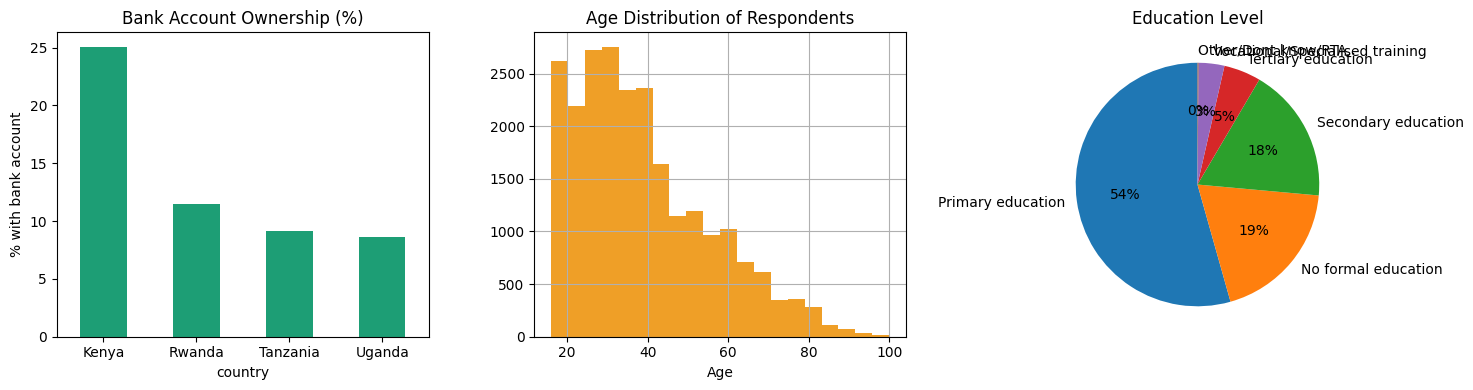

In [10]:
#Lab 8 - Three essential chart types

import matplotlib.pyplot as plt

# ── 1. BAR CHART: bank account ownership by country ───────
ownership = df.groupby("country")["bank_account"].apply(
    lambda x: (x == "Yes").mean() * 100
)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ownership.plot(kind="bar", ax=axes[0], color="#1D9E75")
axes[0].set_title("Bank Account Ownership (%)")
axes[0].set_ylabel("% with bank account")
axes[0].tick_params(axis="x", rotation=0)

# ── 2. HISTOGRAM: age distribution ───────────────────────
df["age_of_respondent"].hist(bins=20, ax=axes[1], color="#EF9F27")
axes[1].set_title("Age Distribution of Respondents")
axes[1].set_xlabel("Age")

# ── 3. PIE CHART: education level breakdown ──────────────
df["education_level"].value_counts().plot(
    kind="pie", ax=axes[2], autopct="%1.0f%%", startangle=90
)
axes[2].set_title("Education Level")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()